<a href="https://colab.research.google.com/github/abhinavguleria001/Stock-Price-Analysis-and-Visualization-AAPL-with-Simple-Moving-Averages/blob/main/cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [2]:
!wget https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip

--2025-08-23 06:07:28--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 23.47.166.62, 2600:1408:c400:168a::317f, 2600:1408:c400:1680::317f
Connecting to download.microsoft.com (download.microsoft.com)|23.47.166.62|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘kagglecatsanddogs_5340.zip’

kagglecatsanddogs_5 100%[===================>] 786.67M   179MB/s    in 4.1s    

2025-08-23 06:07:32 (192 MB/s) - ‘kagglecatsanddogs_5340.zip’ saved [824887076/824887076]



In [5]:
!unzip kagglecatsanddogs_5340.zip


Streaming output truncated to the last 5000 lines.
  inflating: PetImages/Dog/5500.jpg  
  inflating: PetImages/Dog/5501.jpg  
  inflating: PetImages/Dog/5502.jpg  
  inflating: PetImages/Dog/5503.jpg  
  inflating: PetImages/Dog/5504.jpg  
  inflating: PetImages/Dog/5505.jpg  
  inflating: PetImages/Dog/5506.jpg  
  inflating: PetImages/Dog/5507.jpg  
  inflating: PetImages/Dog/5508.jpg  
  inflating: PetImages/Dog/5509.jpg  
  inflating: PetImages/Dog/551.jpg   
  inflating: PetImages/Dog/5510.jpg  
  inflating: PetImages/Dog/5511.jpg  
  inflating: PetImages/Dog/5512.jpg  
  inflating: PetImages/Dog/5513.jpg  
  inflating: PetImages/Dog/5514.jpg  
  inflating: PetImages/Dog/5515.jpg  
  inflating: PetImages/Dog/5516.jpg  
  inflating: PetImages/Dog/5517.jpg  
  inflating: PetImages/Dog/5518.jpg  
  inflating: PetImages/Dog/5519.jpg  
  inflating: PetImages/Dog/552.jpg   
  inflating: PetImages/Dog/5520.jpg  
  inflating: PetImages/Dog/5521.jpg  
  inflating: PetImages/Dog/5522.jpg  

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import warnings
from keras.preprocessing.image import load_img
warnings.filterwarnings('ignore')

In [4]:
input_path = []
label = []
for class_name in os.listdir("PetImages"):
    for path in os.listdir(os.path.join("PetImages",class_name)):
        if class_name == 'Cat':
            label.append(0)
        else:
              label.append(1)
        input_path.append(os.path.join("PetImages", class_name, path))

print(input_path[0],label[0])

PetImages/Cat/7936.jpg 0


In [9]:
df = pd.DataFrame()
df['images']= input_path
df['labels']= label
df = df.sample(frac=1).reset_index(drop=True)
df.head()

,images,labels
0,PetImages/Cat/2942.jpg,0
1,PetImages/Cat/7129.jpg,0
2,PetImages/Cat/5563.jpg,0
3,PetImages/Dog/8192.jpg,1
4,PetImages/Cat/5043.jpg,0


In [54]:
import PIL
l = []
for images in df['images']:
    try:
        img = PIL.Image.open(images)
    except:
        l.append(images)

In [55]:
import os

# Define the root directory where PetImages is located
root_dir = "PetImages"
# Iterate through all subdirectories and files
for dirpath, dirnames, filenames in os.walk(root_dir):
    for filename in filenames:
        if filename.endswith(".db"):
            file_path = os.path.join(dirpath, filename)
            try:
                os.remove(file_path)
                print(f"Deleted: {file_path}")
            except OSError as e:
                print(f"Error deleting {file_path}: {e}")

In [56]:
plt.figure(figsize = (25,25))
temp = df[df['labels']==1]['images']
start = random.randint(0,len(temp))
files = temp[start:start+25]
for index,file in enumerate(files):
    plt.subplot(5,5,index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Dog')
    plt.axis('off')

<Figure size 2500x2500 with 0 Axes>

In [57]:
plt.figure(figsize = (25,25))
temp = df[df['labels']==0]['images']
start = random.randint(0,len(temp))
files = temp[start:start+25]
for index,file in enumerate(files):
    plt.subplot(5,5,index+1)
    img = load_img(file)
    img = np.array(img)
    plt.imshow(img)
    plt.title('Cats')
    plt.axis('off')

<Figure size 2500x2500 with 0 Axes>

<Axes: ylabel='count'>

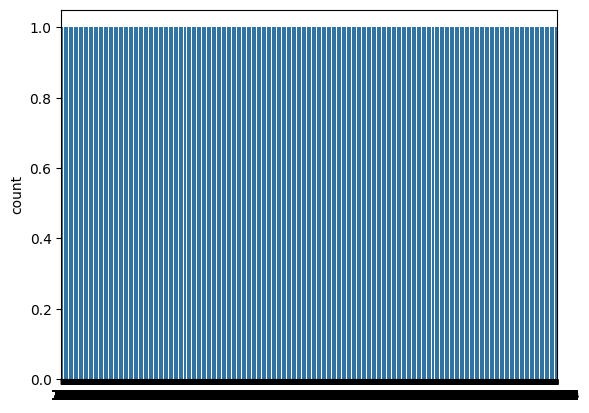

In [71]:
import seaborn as sns
sns.countplot(df['labels'])


In [59]:
from sklearn.model_selection import train_test_split
train,test = train_test_split(df,test_size=0.2,random_state=42)

In [60]:
train.head()

,images,labels
16248,PetImages/Cat/10870.jpg,0
695,PetImages/Cat/9947.jpg,0
17155,PetImages/Dog/6692.jpg,1
21826,PetImages/Cat/5281.jpg,0
1020,PetImages/Cat/8503.jpg,0


In [61]:
test.head()

,images,labels
9254,PetImages/Cat/10518.jpg,0
8049,PetImages/Dog/5763.jpg,1
23757,PetImages/Cat/1340.jpg,0
3463,PetImages/Cat/1585.jpg,0
20539,PetImages/Cat/4448.jpg,0


In [62]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1./255, #normaliztion of image
                                       rotation_range = 40, shear_range = 0.2,zoom_range=0.2, horizontal_flip=True,fill_mode = 'nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

train['labels'] = train['labels'].astype(str)
test['labels'] = test['labels'].astype(str)

train_iterator = train_datagen.flow_from_dataframe(train,x_col='images',y_col='labels',target_size=(150,150),batch_size=32,class_mode= 'binary')
validation_iterator = test_datagen.flow_from_dataframe(test,x_col='images',y_col='labels',target_size=(150,150),batch_size=32,class_mode= 'binary')

Found 19999 validated image filenames belonging to 2 classes.
Found 5001 validated image filenames belonging to 2 classes.


In [63]:
#model creation
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
model = Sequential([
    Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [64]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 148, 148, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 74, 74, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 72, 72, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 34, 34, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │     9,470,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,494,561 (36.22 MB)

 Trainable params: 9,494,561 (36.22 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
import os
from PIL import Image

# List to store paths of valid images
valid_input_path = []
valid_label = []

# Iterate through the original input_path and labels
for img_path, lbl in zip(input_path, label):
    try:
        # Attempt to open the image file
        img = Image.open(img_path)
        # If successful, add the path and label to the valid lists
        valid_input_path.append(img_path)
        valid_label.append(lbl)
    except Exception as e:
        # If an error occurs (e.g., UnidentifiedImageError), print a message and skip the file
        print(f"Skipping corrupted image: {img_path} - {e}")

# Update the input_path and label lists with only valid images
input_path = valid_input_path
label = valid_label

print(f"Number of valid images: {len(input_path)}")

Number of valid images: 24998


In [67]:
# Rebuild DataFrame using only valid images
df = pd.DataFrame({
    "images": valid_input_path,
    "labels": valid_label
})

# Shuffle again
df = df.sample(frac=1).reset_index(drop=True)

# Train-test split
from sklearn.model_selection import train_test_split
train, test = train_test_split(df, test_size=0.2, random_state=42)

train['labels'] = train['labels'].astype(str)
test['labels'] = test['labels'].astype(str)

In [68]:
train_iterator = train_datagen.flow_from_dataframe(
    train,
    x_col='images',
    y_col='labels',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

validation_iterator = test_datagen.flow_from_dataframe(
    test,
    x_col='images',
    y_col='labels',
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 19998 validated image filenames belonging to 2 classes.
Found 5000 validated image filenames belonging to 2 classes.


In [69]:
history = model.fit(train_iterator, epochs=10, validation_data=validation_iterator)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 578s 924ms/step - accuracy: 0.7050 - loss: 0.5702 - val_accuracy: 0.7628 - val_loss: 0.4826
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 580s 928ms/step - accuracy: 0.7511 - loss: 0.5088 - val_accuracy: 0.7802 - val_loss: 0.4607
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 583s 933ms/step - accuracy: 0.7719 - loss: 0.4746 - val_accuracy: 0.7802 - val_loss: 0.4518
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 582s 931ms/step - accuracy: 0.7862 - loss: 0.4520 - val_accuracy: 0.7916 - val_loss: 0.4379
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 594s 950ms/step - accuracy: 0.8069 - loss: 0.4185 - val_accuracy: 0.8338 - val_loss: 0.3758
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 597s 954ms/step - accuracy: 0.8218 - loss: 0.3970 - val_accuracy: 0.8392 - val_loss: 0.3605
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 590s 945ms/step - accuracy: 0.8244 - loss: 0.3828 - val_accuracy: 0.8490 - val_loss: 0.3444
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 594s 950ms/step - accuracy: 0.8353 -

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

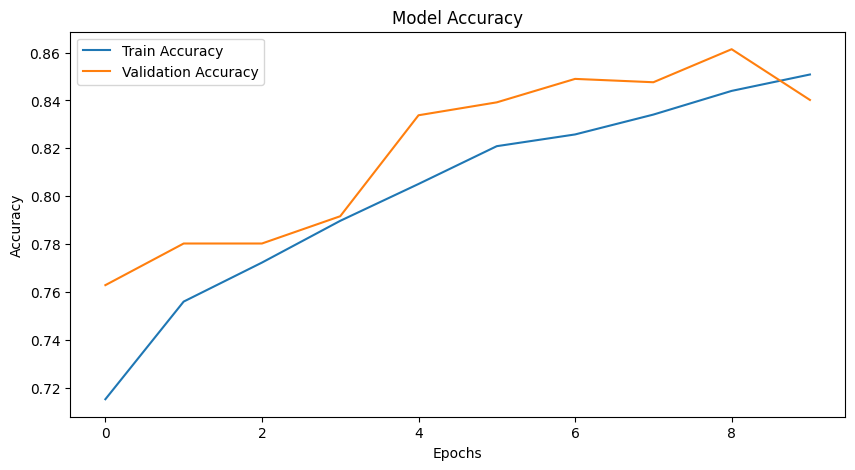

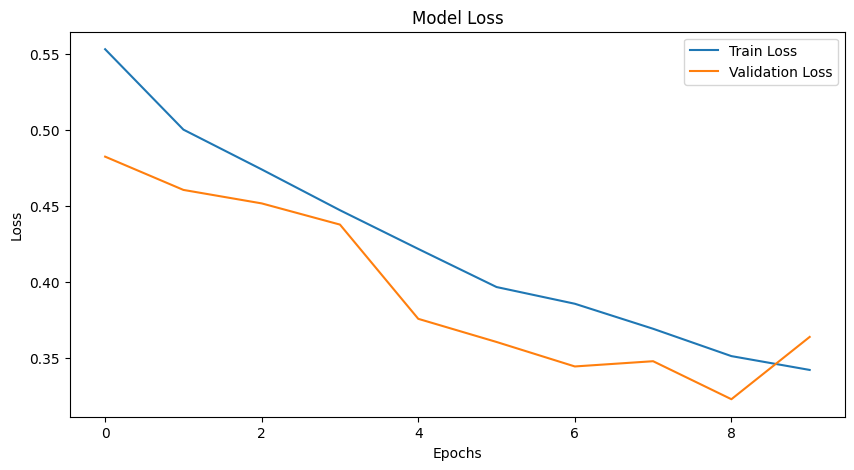

In [70]:
import matplotlib.pyplot as plt

# Plot Training & Validation Accuracy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()